<a href="https://colab.research.google.com/github/sam058/Fake_Job_Prediction/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/fake_job_postings.csv"

In [ ]:
!ls /content/drive/MyDrive/

'AWS Club Tracksheet.gsheet'	     'Photo Collection.gform'
'Colab Notebooks'		      Portfolio.docx
 Curations.gdoc			     'Resume(final).pdf'
 fake_job_postings.csv		     'saumya_dogra[1].docx'
'PBL-4 PPT.pptx'		     'saumya dogra.jpg'
'Photo Collection (File responses)'   wine.csv


In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/fake_job_postings.csv")
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


In [ ]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               17880 non-null  int64 
 1   title                17880 non-null  object
 2   location             17534 non-null  object
 3   department           6333 non-null   object
 4   salary_range         2868 non-null   object
 5   company_profile      14572 non-null  object
 6   description          17879 non-null  object
 7   requirements         15184 non-null  object
 8   benefits             10668 non-null  object
 9   telecommuting        17880 non-null  int64 
 10  has_company_logo     17880 non-null  int64 
 11  has_questions        17880 non-null  int64 
 12  employment_type      14409 non-null  object
 13  required_experience  10830 non-null  object
 14  required_education   9775 non-null   object
 15  industry             12977 non-null  object
 16  func

,0
job_id,0
title,0
location,346
department,11547
salary_range,15012
company_profile,3308
description,1
requirements,2696
benefits,7212
telecommuting,0


In [ ]:
df.fillna('', inplace=True)

In [ ]:
df['text'] = df['title']+""+ df['description']+ " " + df['requirements'] + " " + df['company_profile']

In [ ]:
X = df['text']
y = df['fraudulent']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TF : how often a word appears in a job description

IDF: how rare is that word across all job postings

ex: job - everywhere: low importance
scam or urgent hiring with no experience - rare: high importance

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

baseline model : Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train_vec, y_train)

LogisticRegression(class_weight='balanced')

Using Naive Bayes(for textual data)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

MultinomialNB()

Using Random Forest for comaprison

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_vec, y_train)

RandomForestClassifier()

Comapring Accuracy

In [ ]:
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test_vec)
    print(name, "Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.9630872483221476
Naive Bayes Accuracy: 0.9678411633109619
Random Forest Accuracy: 0.9804250559284117


Classification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3395
           1       0.59      0.86      0.70       181

    accuracy                           0.96      3576
   macro avg       0.79      0.92      0.84      3576
weighted avg       0.97      0.96      0.97      3576



Accuracy Comparison bar chart

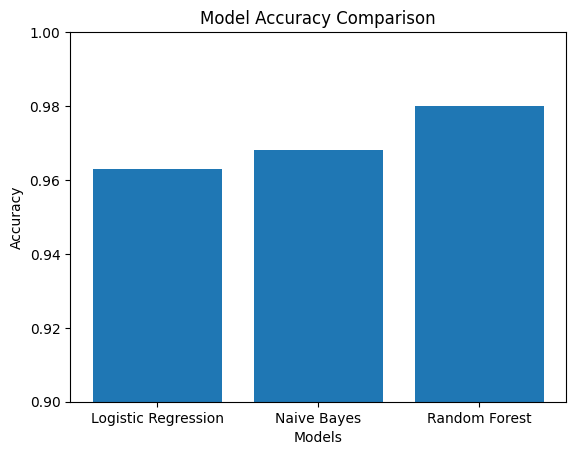

In [ ]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Naive Bayes", "Random Forest"]
accuracies = [0.963, 0.968, 0.980]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0.9, 1.0)
plt.show()

Confusion matrix for best model

<Figure size 640x480 with 0 Axes>

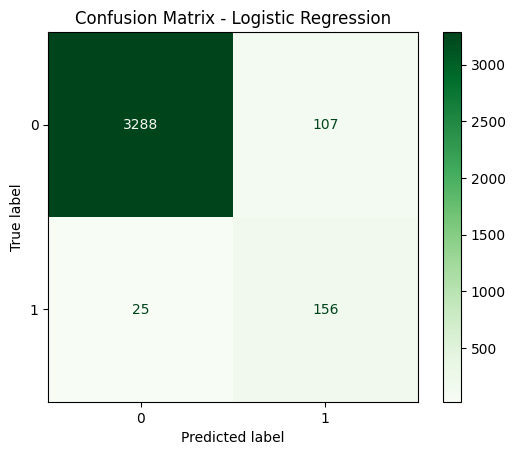

<Figure size 640x480 with 0 Axes>

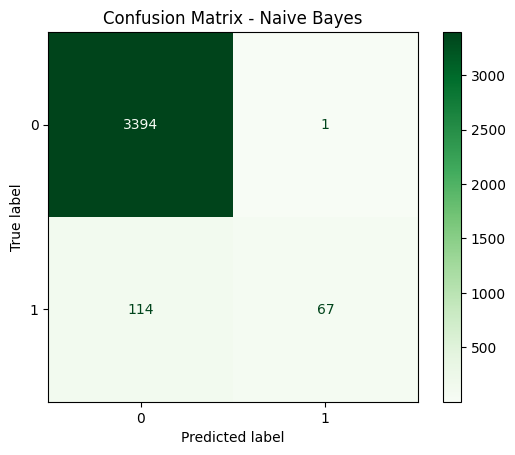

<Figure size 640x480 with 0 Axes>

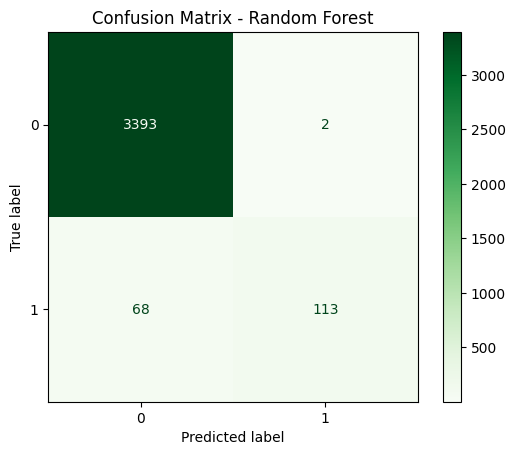

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

models = {
    "Logistic Regression": lr,
    "Naive Bayes": nb,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test_vec)

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    plt.figure()
    disp.plot(cmap="Greens")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

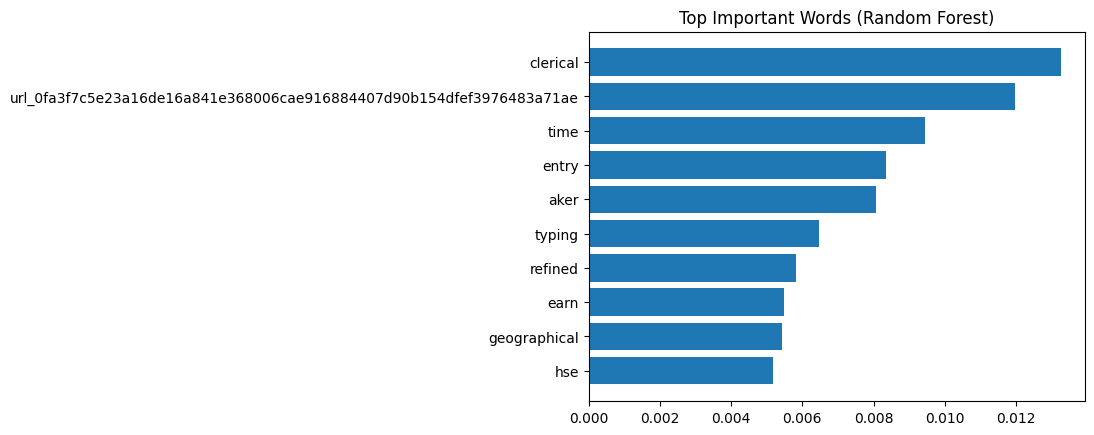

In [ ]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()
importances = rf.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Top Important Words (Random Forest)")
plt.show()

In [ ]:
import pickle

# Save models
pickle.dump(lr, open("lr_model.pkl", "wb"))
pickle.dump(nb, open("nb_model.pkl", "wb"))
pickle.dump(rf, open("rf_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [ ]:
from google.colab import files

files.download("lr_model.pkl")
files.download("nb_model.pkl")
files.download("rf_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>